# Deep Burst SR Colab Starter

This notebook mounts Google Drive, prepares a synthetic RGB dataset from DIV2K, trains the model, and writes checkpoints plus sample outputs to Drive.

In [17]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Not running in Colab: skipping Google Drive mount.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from pathlib import Path

if IN_COLAB:
    %cd /content
    REPO_ROOT = Path('/content/deep_burst_sr_reimplementation')
    if not REPO_ROOT.exists():
        !git clone https://github.com/Karan2005-sys/deep_burst_sr_reimplementation.git {REPO_ROOT}
else:
    REPO_ROOT = Path.cwd()

%cd {REPO_ROOT}
!pip install -r {REPO_ROOT / 'requirements.txt'}
print('Using repo:', REPO_ROOT)


/content
/content/deep_burst_sr_reimplementation
Using repo: /content/deep_burst_sr_reimplementation


In [19]:
if IN_COLAB:
    SYNTH_ROOT = '/content/drive/MyDrive/SyntheticRGB'
    REAL_ROOT = '/content/drive/MyDrive/BurstSR'
    OUTPUT_ROOT = '/content/drive/MyDrive/dbsr_outputs'
else:
    SYNTH_ROOT = '/tmp/SyntheticRGB'
    REAL_ROOT = '/tmp/BurstSR'
    OUTPUT_ROOT = '/tmp/dbsr_outputs'

SYNTH_CONFIG = 'configs/synthetic_rgb.yaml'
REAL_CONFIG = 'configs/real_burstsr.yaml'

print('SYNTH_ROOT:', SYNTH_ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)


SYNTH_ROOT: /content/drive/MyDrive/SyntheticRGB
OUTPUT_ROOT: /content/drive/MyDrive/dbsr_outputs


In [20]:
from pathlib import Path
import subprocess
import sys

# Read requirement line from requirements.txt
req_text = Path("requirements.txt").read_text(encoding="utf-8-sig").splitlines()
datasets_req = next(
    (line.strip() for line in req_text if line.strip().startswith("datasets")),
    "datasets (not pinned)"
)
print("requirements.txt entry:", datasets_req)

# Show installed package metadata without importing datasets
show = subprocess.run(
    [sys.executable, "-m", "pip", "show", "datasets"],
    capture_output=True,
    text=True
)

if show.returncode != 0:
    print("datasets is not installed yet.")
else:
    for line in show.stdout.splitlines():
        if line.startswith(("Name:", "Version:", "Location:")):
            print(line)

requirements.txt entry: datasets>=2.19
Name: datasets
Version: 2.19.2
Location: /usr/local/lib/python3.12/dist-packages


In [21]:
# Replace your problematic datasets check/install cell with this (pure Python, no heredoc)

from pathlib import Path
import subprocess
import sys

# 1) Show what requirements.txt expects
req_text = Path("requirements.txt").read_text(encoding="utf-8-sig").splitlines()
datasets_req = next((ln.strip() for ln in req_text if ln.strip().startswith("datasets")), "datasets (not pinned)")
print("requirements.txt entry:", datasets_req)

# 2) Install a compatible datasets range (avoids v4 script-loader breakage)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "datasets>=2.19,<4"],
    check=True,
)

# 3) Verify installed version without importing datasets
show = subprocess.run(
    [sys.executable, "-m", "pip", "show", "datasets"],
    capture_output=True,
    text=True,
    check=False,
)
print("\n[datasets]")
if show.returncode != 0:
    print("not installed")
else:
    for line in show.stdout.splitlines():
        if line.startswith(("Name:", "Version:", "Location:")):
            print(line)

requirements.txt entry: datasets>=2.19

[datasets]
Name: datasets
Version: 2.19.2
Location: /usr/local/lib/python3.12/dist-packages


## Prepare synthetic RGB data from DIV2K
This creates `train/` and `val/` under `SYNTH_ROOT` automatically using DIV2K HR images.

In [22]:
!mkdir -p {OUTPUT_ROOT}
!python {REPO_ROOT / 'scripts' / 'prepare_div2k_synthetic.py'} --output-root {SYNTH_ROOT}



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/content/deep_burst_sr_reimplementation/scripts/prepare_div2k_synthetic.py", line 7, in <module>
    from datasets import load_dataset
  File "/usr/local/lib/python3.12/dist-packages/datasets/__init__.py", line 18, in <module>
    from .arrow_dataset import Dataset
  File "/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py", line 59, in <module>
    import pandas as pd
  File "/usr/local/lib/python3.12/dist-packages/pandas/__init__.py", line 26, in <module>
    from pandas.compat import (
  File "/us

In [16]:
!python {REPO_ROOT / 'scripts' / 'train.py'} --config {REPO_ROOT / SYNTH_CONFIG} --data-root {SYNTH_ROOT} --output-dir {OUTPUT_ROOT}/synthetic_run


2026-04-16 18:02:58.237414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776362578.258323   15683 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776362578.265249   15683 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776362578.283617   15683 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776362578.283641   15683 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776362578.283645   15683 computation_placer.cc:177] computation placer alr

In [23]:
!find {OUTPUT_ROOT}/synthetic_run -maxdepth 3 -type f | sort | tail -n 20

/content/drive/MyDrive/dbsr_outputs/synthetic_run/epoch_001.pt
/content/drive/MyDrive/dbsr_outputs/synthetic_run/epoch_002.pt
/content/drive/MyDrive/dbsr_outputs/synthetic_run/epoch_003.pt
/content/drive/MyDrive/dbsr_outputs/synthetic_run/epoch_004.pt
/content/drive/MyDrive/dbsr_outputs/synthetic_run/epoch_005.pt
/content/drive/MyDrive/dbsr_outputs/synthetic_run/tb/events.out.tfevents.1776356286.9ff68a874f4e.10740.0
/content/drive/MyDrive/dbsr_outputs/synthetic_run/tb/events.out.tfevents.1776360131.18b9b08651c3.9507.0
/content/drive/MyDrive/dbsr_outputs/synthetic_run/tb/events.out.tfevents.1776362593.c8393ca8e37e.15683.0
/content/drive/MyDrive/dbsr_outputs/synthetic_run/visuals/epoch_001/prediction.png
/content/drive/MyDrive/dbsr_outputs/synthetic_run/visuals/epoch_001/target.png
/content/drive/MyDrive/dbsr_outputs/synthetic_run/visuals/epoch_002/prediction.png
/content/drive/MyDrive/dbsr_outputs/synthetic_run/visuals/epoch_002/target.png
/content/drive/MyDrive/dbsr_outputs/synthetic_r

Latest preview folder: /content/drive/MyDrive/dbsr_outputs/synthetic_run/visuals/epoch_005


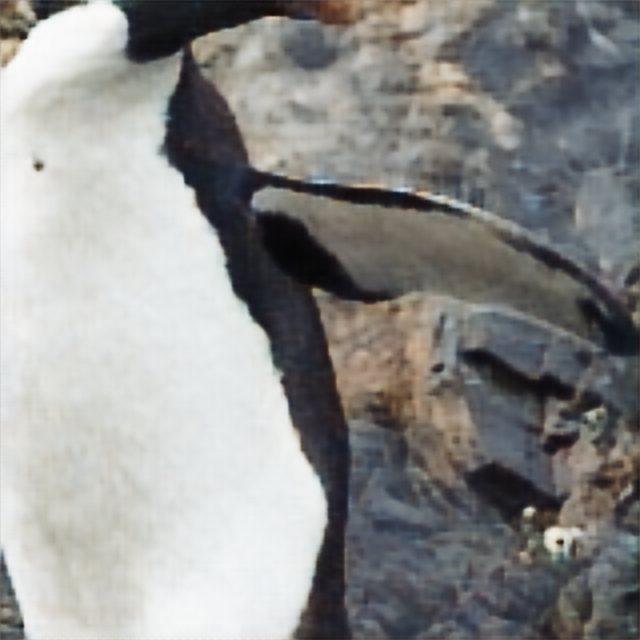

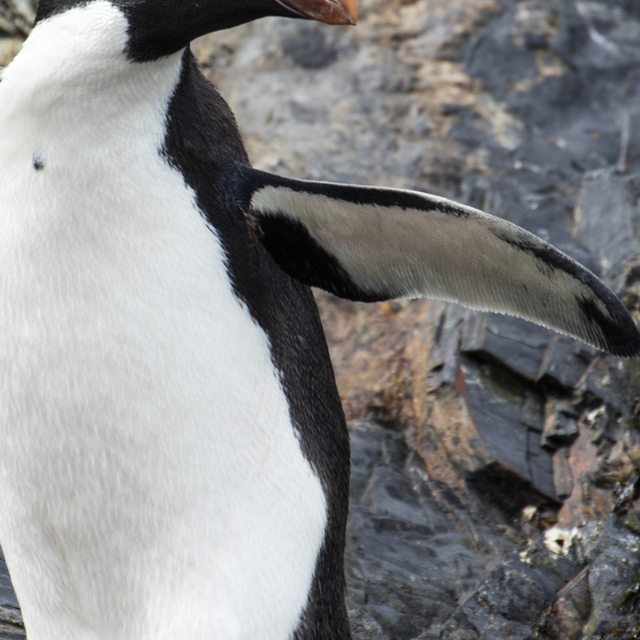

In [24]:
from IPython.display import display
from PIL import Image
from pathlib import Path

visual_root = Path(OUTPUT_ROOT) / 'synthetic_run' / 'visuals'
epoch_dirs = sorted([p for p in visual_root.glob('epoch_*') if p.is_dir()])
latest = epoch_dirs[-1] if epoch_dirs else None
print('Latest preview folder:', latest)
if latest is not None:
    display(Image.open(latest / 'prediction.png'))
    display(Image.open(latest / 'target.png'))

## Later: switch to real BurstSR
When the real dataset is available, point `REAL_ROOT` to it and run the command below.

In [25]:
# !python {REPO_ROOT / 'scripts' / 'train.py'} --config {REPO_ROOT / REAL_CONFIG} --data-root {REAL_ROOT} --output-dir {OUTPUT_ROOT}/real_run
